## Lab - EDA Univariate Analysis: Diving into Amazon UK Product Insights

**Objective**: Explore the product listing dynamics on Amazon UK to extract actionable business insights. By understanding the distribution, central tendencies, and relationships of various product attributes, businesses can make more informed decisions on product positioning, pricing strategies, and inventory management.

**Dataset**: This lab utilizes the [Amazon UK product dataset](https://www.kaggle.com/datasets/asaniczka/uk-optimal-product-price-prediction/)
which provides information on product categories, brands, prices, ratings, and more from from Amazon UK. You'll need to download it to start working with it.




### Part 1: Understanding Product Categories

**Business Question**: What are the most popular product categories on Amazon UK, and how do they compare in terms of listing frequency?

1. **Frequency Tables**:
    - Generate a frequency table for the product `category`.
    - Which are the top 5 most listed product categories?



In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import kagglehub
import matplotlib.pyplot as plt
from kagglehub import KaggleDatasetAdapter



In [2]:
df = pd.read_csv("amz_uk_price_prediction_dataset.csv")

In [3]:
df.head(5)

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [4]:
top_5 = df["category"].value_counts().head(5)
print(top_5)

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Name: count, dtype: int64


2. **Visualizations**:
    - Display the distribution of products across different categories using a bar chart. *If you face problems understanding the chart, do it for a subset of top categories.*
    - For a subset of top categories, visualize their proportions using a pie chart. Does any category dominate the listings?

---

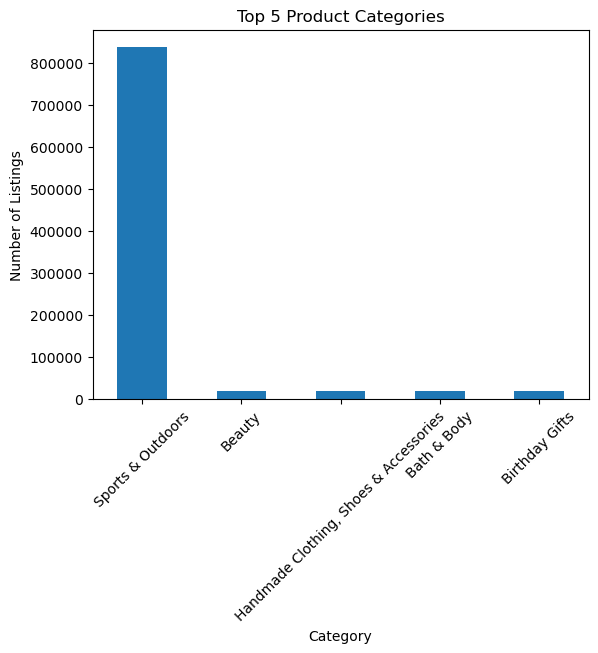

In [5]:
top_5.plot(kind="bar")
plt.title("Top 5 Product Categories")
plt.xlabel("Category")
plt.ylabel("Number of Listings")
plt.xticks(rotation=45)
plt.show()

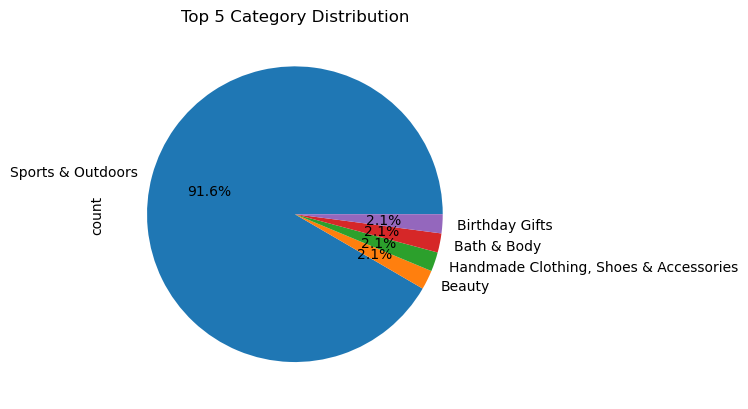

In [31]:

top_5.plot(kind="pie", autopct="%1.1f%%")
plt.title("Top 5 Category Distribution")
plt.show()

### Part 2: Delving into Product Pricing

**Business Question**: How are products priced on Amazon UK, and are there specific price points or ranges that are more common?

1. **Measures of Centrality**:
    - Calculate the mean, median, and mode for the `price` of products.
    - What's the average price point of products listed? How does this compare with the most common price point (mode)?


In [7]:
mean_price = df["price"].mean()
median_price = df["price"].median()
mode_price = df["price"].mode()[0]

print("Mean:", mean_price)
print("Median:", median_price)
print("Mode:", mode_price)

Mean: 89.24380943923661
Median: 19.09
Mode: 9.99


2. **Measures of Dispersion**:
    - Determine the variance, standard deviation, range, and interquartile range for product `price`.
    - How varied are the product prices? Are there any indicators of a significant spread in prices?

In [8]:
price = df["price"]

variance = price.var()
std_dev = price.std()
price_range = price.max() - price.min()
iqr = price.quantile(0.75) - price.quantile(0.25)

print("Variance:", variance)
print("Standard Deviation:", std_dev)
print("Range:", price_range)
print("IQR:", iqr)

Variance: 119445.48532256528
Standard Deviation: 345.60886175352226
Range: 100000.0
IQR: 36.0


3. **Visualizations**:
    - Is there a specific price range where most products fall? Plot a histogram to visualize the distribution of product prices. *If its hard to read these diagrams, think why this is, and explain how it could be solved.*.
    - Are there products that are priced significantly higher than the rest? Use a box plot to showcase the spread and potential outliers in product pricing. 
    

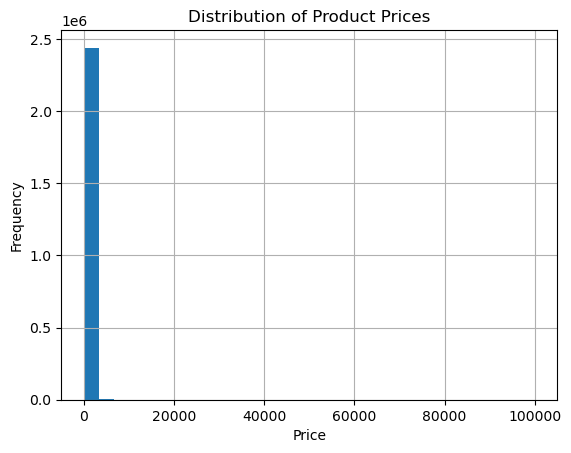

In [9]:
df["price"].hist(bins=30)
plt.title("Distribution of Product Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

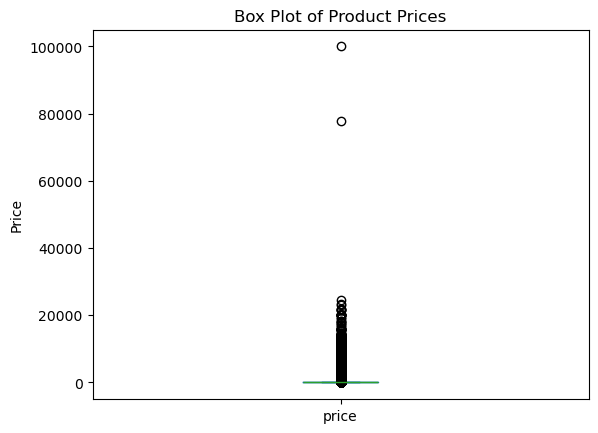

In [10]:
#using a box plot due to extreme price variation
df["price"].plot(kind="box")
plt.title("Box Plot of Product Prices")
plt.ylabel("Price")
plt.show()

### Part 3: Unpacking Product Ratings

**Business Question**: How do customers rate products on Amazon UK, and are there any patterns or tendencies in the ratings?

1. **Measures of Centrality**:
    - Calculate the mean, median, and mode for the `rating` of products.
    - How do customers generally rate products? Is there a common trend?


In [11]:
(df["stars"] == 0).sum() 

np.int64(1225641)

In [12]:
rated = df[df["stars"] > 0]
rated.head(20)

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers
5,6,B09B97WSLF,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
6,7,B09B9615X2,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
7,8,B01MTB55WH,Anker Soundcore 2 Portable Bluetooth Speaker w...,4.7,103673,39.99,False,0,Hi-Fi Speakers
8,9,B016MO90GW,"Bluetooth Speaker, Anker Soundcore Speaker Upg...",4.7,29909,29.99,False,0,Hi-Fi Speakers
9,10,B09ZQF5GZW,RIENOK Bluetooth Speaker Portable Wireless Blu...,4.5,16014,29.99,False,0,Hi-Fi Speakers


In [18]:
rated_mean = rated["stars"].mean()
rated_median = rated["stars"].median()
rated_mode =rated["stars"].mode()[0]

print("rated mean: ", rated_mean , "\nrated median: ", rated_median, "\nrated Mode: ", rated_mode)

rated mean:  4.319160762226911 
rated median:  4.4 
rated Mode:  4.5


2. **Measures of Dispersion**:
    - Determine the variance, standard deviation, and interquartile range for product `rating`.
    - Are the ratings consistent, or is there a wide variation in customer feedback? low std of ratings means not wide spread with a median of 4.4 and a mean of 4.31

In [23]:
rating_varience = rated["stars"].var()
rating_std = rated["stars"].std()
rating_iqr = rated["stars"].quantile(0.75) - rated["stars"].quantile(0.25)


In [25]:
print("Variance:", rating_varience)
print("Standard Deviation:", rating_std)
print("IQR:", rating_iqr)

Variance: 0.3083433752380519
Standard Deviation: 0.5552867504614637
IQR: 0.5


3. **Shape of the Distribution**:
    - Calculate the skewness and kurtosis for the `rating` column. 
    - Are the ratings normally distributed, or do they lean towards higher or lower values? they are not normally distributed, they lean towards higher values with a negative skew of 2.3

In [26]:
ratings = df[df["stars"] > 0]["stars"]

rating_skew = ratings.skew()
rating_kurt = ratings.kurt()

print("Skewness:", rating_skew)
print("Kurtosis:", rating_kurt)

Skewness: -2.379568112212799
Kurtosis: 9.78193769066435



4. **Visualizations**:
    - Plot a histogram to visualize the distribution of product ratings. Is there a specific rating that is more common?


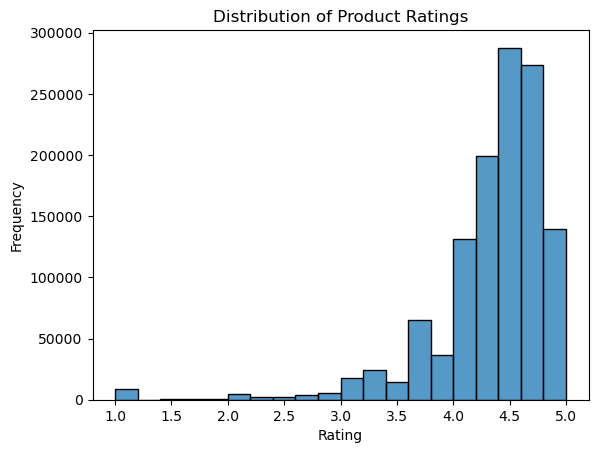

In [28]:
sns.histplot(rated["stars"], bins=20)
plt.title("Distribution of Product Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()